### **3.1 Time Series Data Preprocessing**

In this activity we will focus on preparing your time series data for forecasting models. We will be using the same libraries in Python that you've used in your predictive analytics and machine learning courses.

This is a code along exercise so that you get used to some basic data preprocessing for time series. This is in addition to what you've learned previously in your other courses.

The following are the Python SciPy libraries that we are using:
- NumPy
- Matplotlib
- Pandas

The goal of this activity is for you to learn:
- how to plot time series data
- how to decompose the time series data
- how to apply transformations

**Data Description**

We will be using the data that we discussed in the content videos (JohnsonAndJohnson.csv). The data contains Johnson and Johnson quarterly earnings from 1960-1980.

Attributes:
- time (YYY-MM) year and the quarterly month
- JohnsonJohnson is a float value that represents the earnings per share (EPS)

#### Part 1 - Data Preparation and Distribution Analysis

**Step 1.1 Import Libraries**

In [26]:
# Install required packages if not already installed
# python -m pip install pandas numpy matplotlib
# python -m pip install --upgrade pip
# python -m pip install ipykernel
# python -m pip install scipy
# python -m pip install statsmodels
# python -m pip install workalendar

#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy.stats import boxcox
from scipy.stats import normaltest
from scipy.optimize import minimize
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from workalendar.oceania.australia import Australia
from typing import List
from dateutil.relativedelta import relativedelta, TH
import datetime as dt
from workalendar.oceania.australia import AustralianCapitalTerritory

**Step 1.2 Import Data**

In this step, please upload the `JohnsonAndJohnson.csv` and `JohnsonAndJohnsonCompetitor.csv` files.

In [2]:
df = pd.read_csv(".\\data\\JohnsonAndJohnson_4.csv")
df.head()

,time,JohnsonJohnson
0,1/1/1960,0.71
1,1/4/1960,0.63
2,2/7/1960,0.85
3,1/10/1960,0.44
4,1/1/1961,0.61


**Step 1.3 Check if the month is a time series object**

We can see that **JohnsonJohnson** attribute is float. **time** is stored as a str object for now.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            84 non-null     str    
 1   JohnsonJohnson  84 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.4 KB


**Step 1.4 Convert Month into DateTime format**

We can see that the format of our date is Day?Month/Year. By default, the `pandas.to_time` method assumes Year/Month/Day, so we use the parameter `dayfirst = True` for a correct conversion.

In [4]:
df["time"] = pd.to_datetime(df["time"], dayfirst=True)

In [5]:
# we will make time the index so that we can filter data
# by year, month, days, weekend, specific range etc...
df = df.set_index("time")
# ensure the time series is in correct chronological order
df = df.sort_index()
df.head()

,JohnsonJohnson
time,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61


In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 84 entries, 1960-01-01 to 1980-10-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   JohnsonJohnson  84 non-null     float64
dtypes: float64(1)
memory usage: 1.3 KB


**Step 1.5 Check Distribution of Original Data**

**What Are We Looking For?**

**1. Skewness**

If the data is heavily skewed (e.g., values are mostly low but but with some high outliers), it may affect model accuracy and forecast reliability.

While **skewness in the raw data doesn't break time series models directly**, skewness in the raw data may indicate:

- The presence of outliers or rare extreme values.

- That the **variance increases with the level of the series** (i.e. multiplicative behaviour).

- That the data may not be suitable for models assuming a symmetric or stable distribution.

**2. Variance Stability**

If the variability in the data increases over time (larger values are more volatile), this indicates non-constant variance. Many forecasting models assume constant variance (homoscedasticity).

**3. Need for Transformation**

If we see skewed data or increasing spread, it may be appropriate to apply a transformation such as Box-Cox. This can help:

- Stabilise variance

- Make the data more symmetric

- Improve model performance and the reliability of forecast intervals.

**How Do We Check?**

We inspect the distribution of the original series using a histogram. If necessary, we apply the Box-Cox transformation and compare the result. A well-shaped distribution is more suitable for modelling.

**Why It Matters for Forecasting**

If the data shows increasing spread (i.e. variance grows with the level of the series), it may be appropriate to apply a transformation - such as the Box-Cox transformation.

Transformations can help to:

- Stabilise variance across time

- Improve model assumptions (e.g. residuals that are normally distributed and homoscedastic)

- Support more reliable forecast intervals and inference

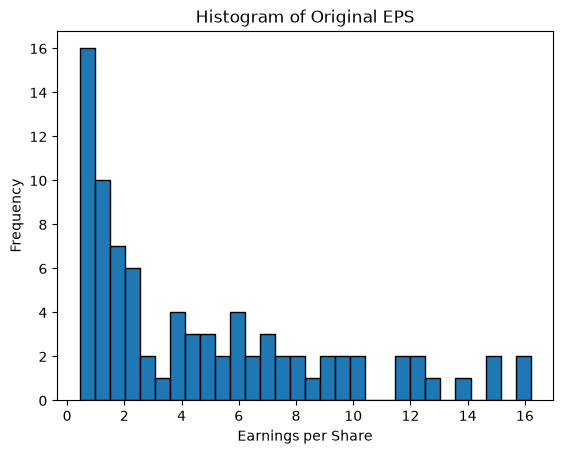

In [7]:
plt.hist(df["JohnsonJohnson"], bins=30, edgecolor='black')
plt.xlabel("Earnings per Share")
plt.ylabel("Frequency")
plt.title("Histogram of Original EPS")
plt.show()

**Step 1.6 Apply Box-Cox Transformation (requires strictly positive data)**

From the distribution plot, we can see that the data is skewed. Let's not plot the original time series to visually assess whether the variance appears to be constant over time.

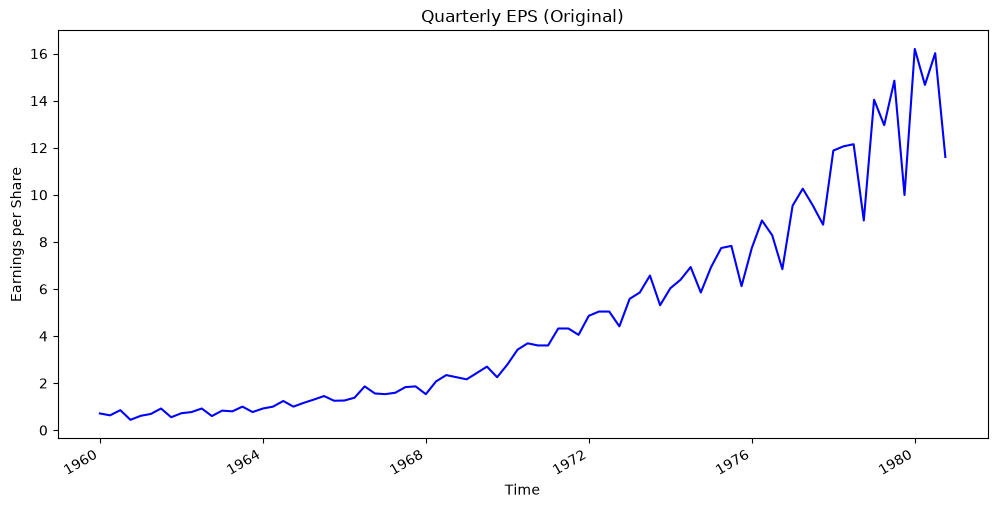

In [8]:
# Visualise Original Time Series

df["JohnsonJohnson"].plot(figsize=(12, 6), title="Quarterly EPS (Original)", color='blue')
plt.xlabel("Time")
plt.ylabel("Earnings per Share")
plt.show()

As you can see from the time series plot, **the variance does not appear to be constant** - it increases over time. This pattern suggests that a **variance-stabilising transformation, such as Box-Cox**, may be appropriate before modelling.

**What is the Box-Cox Transformation?**

The Box-Cox transformation is a mathematical technique used to **stabilise the variance** and make a time series more symmetric (closer to a normal distribution). It is particularly useful when the variability in a series increases with its level, which can negatively affect model performance.

This transformation is defined as:

- If $\lambda\ne0:$

$$y^{(\lambda)}=\frac{y^\lambda-1}{\lambda}$$

- If $\lambda=0:$

$$y^{(\lambda)}=\ln(y)$$

The transformation is applied to the raw (positive-only) data, and the optimal $\lambda$ is chosen automatically to best normalise the data and stabilise its variance.

**Why Use It?**

- To reduce skewness in the data

- To stabilise increasing or decreasing variance over time

- To improve the assumptions of classical forecasting models (e.g., ARIMA), which often expect constant variance and normally distributed residuals.

>> **Note:** The Box-Cox transformation **only works with strictly positive values**. If your series contains zeros or negative values, an alternative like the Yeo-Johnson transformation is required.

In [9]:
# apply box-cox transformation to the data to stabilise variance and make it more normally distributed
# in logarithmic or power transform, there is lambda parameter
# we will use the boxcox function with the default
# parameter value for "lmbda", which is "None"
# "None" value will find the optimal lambda value.
ext, lmbda = boxcox(df["JohnsonJohnson"])
xts = pd.Series(ext, index=df.index)

print(f"Optimal lambda value for Box-Cox transformation: {lmbda:.4f}")

Optimal lambda value for Box-Cox transformation: 0.0507


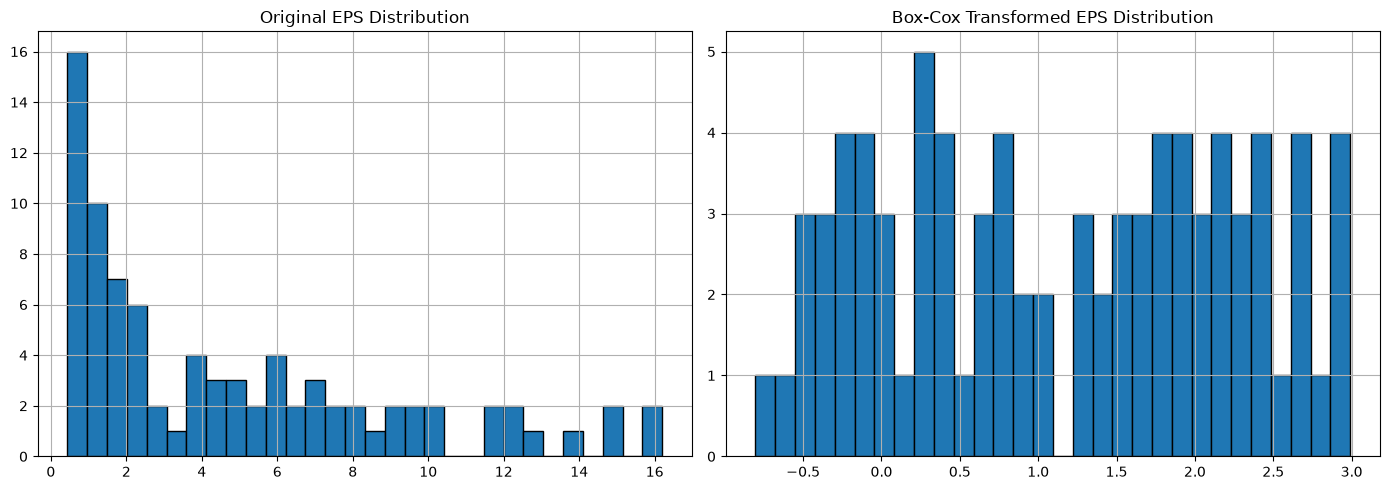

In [10]:
# Visualise Transformed Series and Compare Distributions

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df["JohnsonJohnson"].hist(ax=ax[0], bins=30, edgecolor='black')
ax[0].set_title("Original EPS Distribution")
xts.hist(ax=ax[1], bins=30, edgecolor='black')
ax[1].set_title("Box-Cox Transformed EPS Distribution")
plt.tight_layout()
plt.show()

We can double-check our visual conclusion about the distribution using a statistical test.

Here, we will apply a log transformation and use a statistical test (`normaltest`) to assess whether the transformed data is approximately normally distributed.

**This isn't required for time series models**, but it helps us understand whether the transformation improved the distribution.

A higher p-value (typically > 0.05) suggests that the data does not significantly differ from a normal distribution.

In [11]:
# Perform the normality test on the transformed series
stat, pvalue = normaltest(xts)

print(f"Normality test statistic: {stat:.4f}, p-value: {pvalue:.4f}")

# Interpret the results
if pvalue < 0.05:
    print("The transformed series is likely not normally distributed (reject H0).")
else:
    print("The transformed series appears approximately normally distributed (fail to reject H0).")

Normality test statistic: 40.5921, p-value: 0.0000
The transformed series is likely not normally distributed (reject H0).


>> **Note:** Box-Cox does not guarantee normality because it actually does not really check for normality; the method checks for the smallest standard deviation. In the plots above, the boxcox transformation did not really convert the dataseries into a normal distribution.

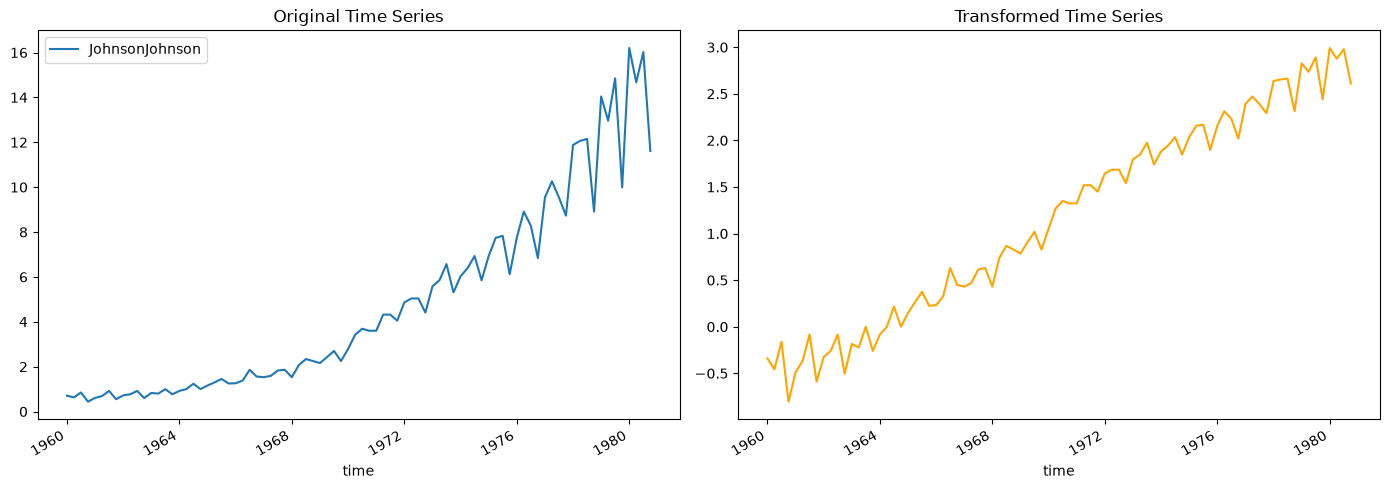

In [12]:
# Let us see what the dataset look like before and after the transformation
# there will be two plots

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Original Time Series
df.plot(ax=ax[0])

# Transformed Time Series
xts.plot(ax=ax[1], color='orange')

# Labels and Titles
ax[0].set_title("Original Time Series")
ax[1].set_title("Transformed Time Series")

plt.tight_layout()
plt.show()

As you can see from the plots above, the boxcox transformation looks a bit more stable than the original dataseries.

**Step 1.7 Explore Log transformation**

**Log transformation** is commonly used in data science and machine learning to reduce skewness and stablisise variance - especially when values grow exponentially or variance increases with the level of the data.

In time series analysis, log transformation is often applied before modelling to make the series more suitable for methods that assume constant variance.

In [13]:
# use log transform
log_transformed = np.log(df)
_, p = normaltest(log_transformed)

# removing the value from the dataframe so that we can format it
index = 0
pvalue = p[index]
print("significance: %.4f" % pvalue)

significance: 0.0000


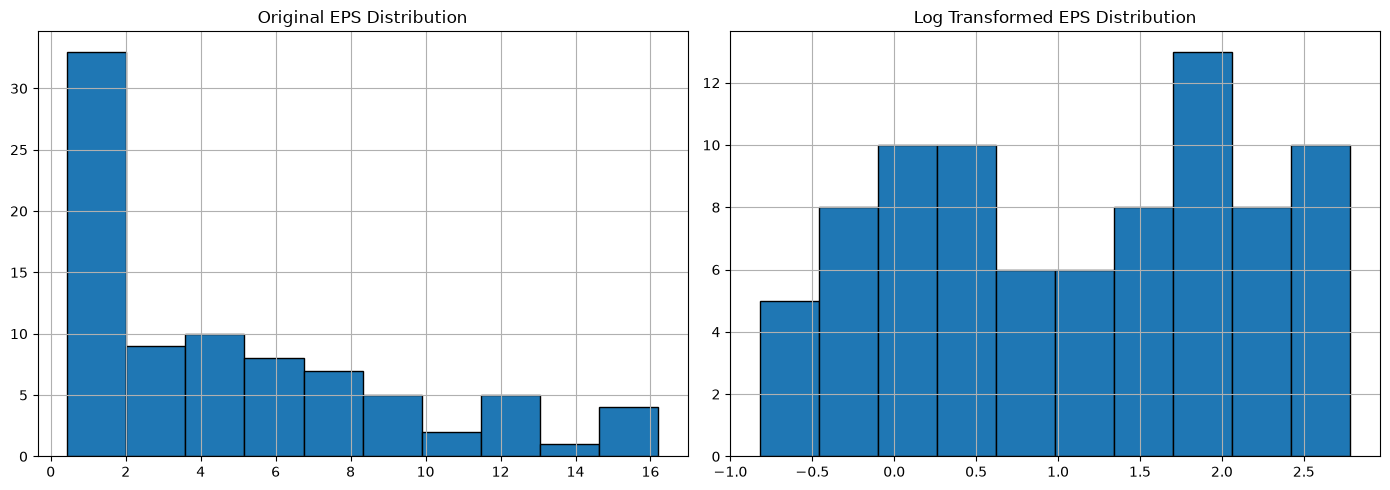

In [14]:
# Visualise Log Transformed Series and Compare Distributions

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df.hist(ax=ax[0], edgecolor='black')
ax[0].set_title("Original EPS Distribution")
log_transformed.hist(ax=ax[1], edgecolor='black')
ax[1].set_title("Log Transformed EPS Distribution")
plt.tight_layout()
plt.show()

**Conclusion**

The **Box-Cox transformation** has improved the **distribution of the data**, though it is still not fully **normal**. This is often the case in real-world **time series**.

At this point, the data is **not normally distributed - and that's usually fine**. In **time series forecasting, normality of the raw data is not a required assumption**. Instead, what matters more is:

- Whether the **residuals** from your model are approximately **normally distributed**

- Whether **variance is stable**

- Whether the residuals resemble **white noise** (uncorrelated, zero mean)

Further **data cleaning or preprocessing** may help on specific cases (e.g., outlier removal), but there is **no need to force the data to be normally distributed** unless the method you're using explicitly requires it (e.g., for some types of statistical inference).

>> **Takeaway: Normality is not essential for forecasting accuracy**. Focus on making sure your **model assumptions hold**, especially in the **residuals**, rather than trying to make the original data look perfectly normal.

#### Part 2 - Plotting time series data using pandas

You have already seen in the previous codes how to plot histograms and your data series.

In this part, you will learn how to code more visualisations.

As you've seen earlier, plotting in pandas can be done by adding **.plot** to the dataframe: df.plot()

Let us use another data set called **JohnsonAndJohnsonCompetitor.csv**. The attributes are:

- time: quarter dates from 1960-1980 (year and month)

- JohnsonJohnson: earning per share in J&J per quarter

- Competitor: competitor's earning per share per quarter

In [15]:
# read the dataset
df2 = pd.read_csv(".\\data\\JohnsonAndJohnsonCompetitor.csv")
df2.head()

,time,JohnsonJohnson,Competitor
0,1/1/1960,0.71,1.71
1,1/4/1960,0.63,-1.37
2,2/7/1960,0.85,-1.15
3,1/10/1960,0.44,0.44
4,1/1/1961,0.61,-0.39


**Step 2.1 Plot the entire data series**

Plot all columns in the time series

<Axes: title={'center': 'Quarterly EPS Comparison'}>

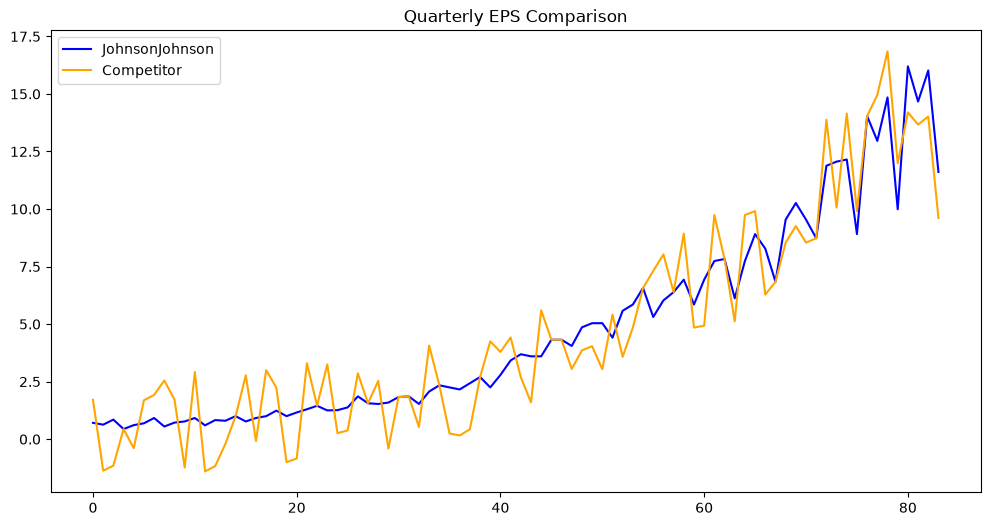

In [16]:
# By default .plot is a line graph
df2.plot(kind='line', figsize=(12, 6), title="Quarterly EPS Comparison", color=['blue', 'orange'])

**Step 2.2 Plot each column separately**

We use subplots and change the subplots parameter to **True**

array([[<Axes: >],
       [<Axes: >]], dtype=object)

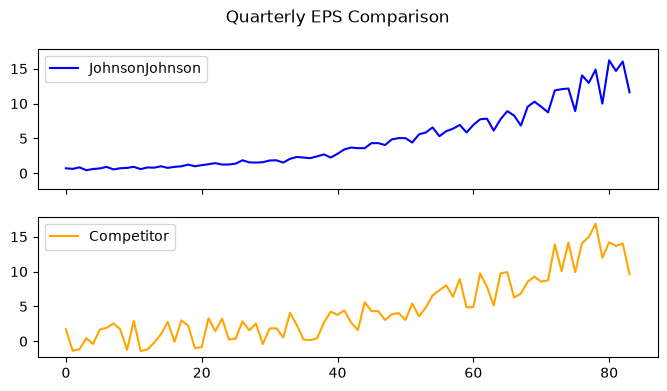

In [17]:
fig_dims = (8, 4)
df2.plot(figsize=fig_dims, title="Quarterly EPS Comparison", color=['blue', 'orange'], subplots=True, layout=(2, 1), sharex=True, sharey=True)

There are other ways to plot your time series data and you can even make them interactive using **hvPlot**.

For more details, you can go to this site: [hvPlot](https://hvplot.holoviz.org/en/docs/latest/#)

#### Part 3 Decomposing Time Series Data into Components

When performing time series analysis, one of your objectives may be forecasting, where you build a model to make a future prediction. Before starting the modelling process, you will need to extract the components of the time series process for analysis.

We will learn how to decompose into season, trend and residual.

We will be using our original **JohnsonAndJohnson.csv** file which as stored in the `df` dataframe.

**Step 3.1 Seasonal Decompose**

We will use the statsmodel's `seasonal_decompose` approach. Please note that we know this is **quarterly data**.

In [18]:
# By default statsmodel are small so we set .rcParams to make them larger for better visibility in the notebook
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

<Axes: xlabel='time'>

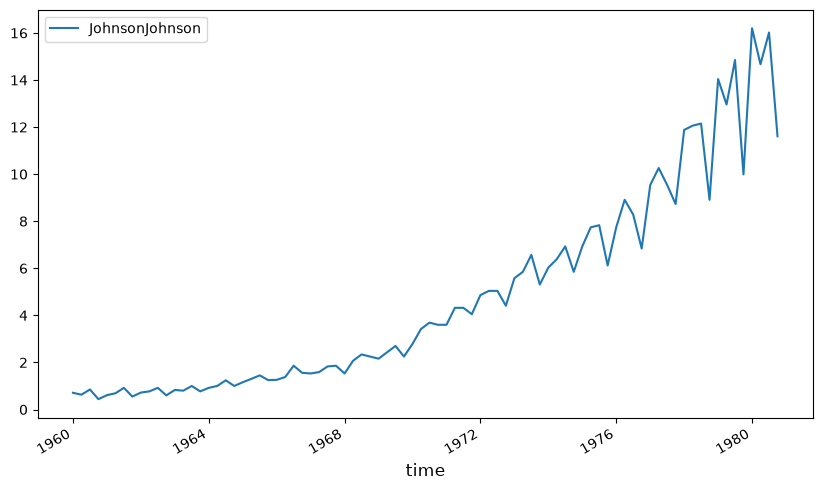

In [19]:
# Let's plot the time series to understand whether the seasonality shows multiplicative or additive behaviour.
df.plot()

The J&J earnings per share is showing trend but we are not sure about the season variations. Let's see if we use additive and multiplicative what will happen.

>> **Note:** If the size of the seasonal ups and downs increases as the series level increases, try a **multiplicative** model. If the seasonal pattern stays the same size over time, try an **additive** model.

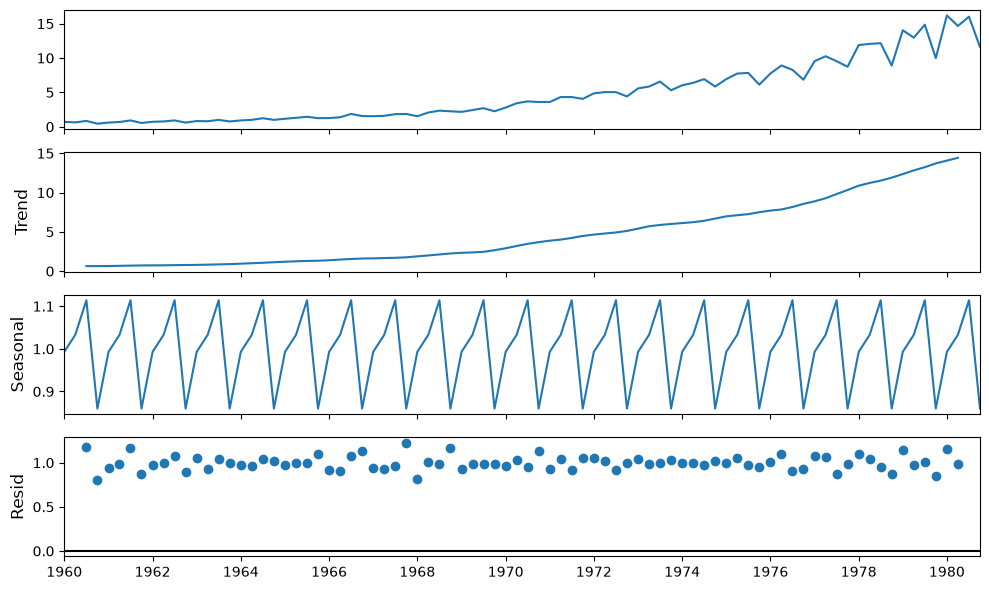

In [20]:
# decompose using seasonal_decompose() function
# Because the time series was contrived and was provided as an array of numbers
# we must specify the frequency of the observations
# (e.g., period = 1 for annual, 4 for quarterly, etc.)
# If a pandas series object is provided, this argument is not required.
df_decomposed = seasonal_decompose(df, model='multiplicative', period=4)

# plot them and let us make the figure size a bit bigger for better visibility
plt.rcParams["figure.figsize"] = (10, 6)
df_decomposed.plot()
plt.show()

The plot has four parts:

1. This is the original observed data that we are decomposing.

2. The trend component shows an upward direction. The trend indicates whether there is positive (increasing or upward), negative (decreasing or downward), or constant (no trend or horizontal) long-term movement.

3. The seasonal component shows the seasonality effect.

4. The residual (noise) component shows the random variation in the data after applying the model. In this case, an additive model was used.

Let's try a more advanced technique to get the seasonality.

**Using STL**

STL is a versatile and robust method for decomposing time series. STL is an acronym for "Seasonal and Trend decomposition using Loess", while loess is a method for estimating nonlinear relationships.

For explanations of parameters of STL, go to this [site](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html)

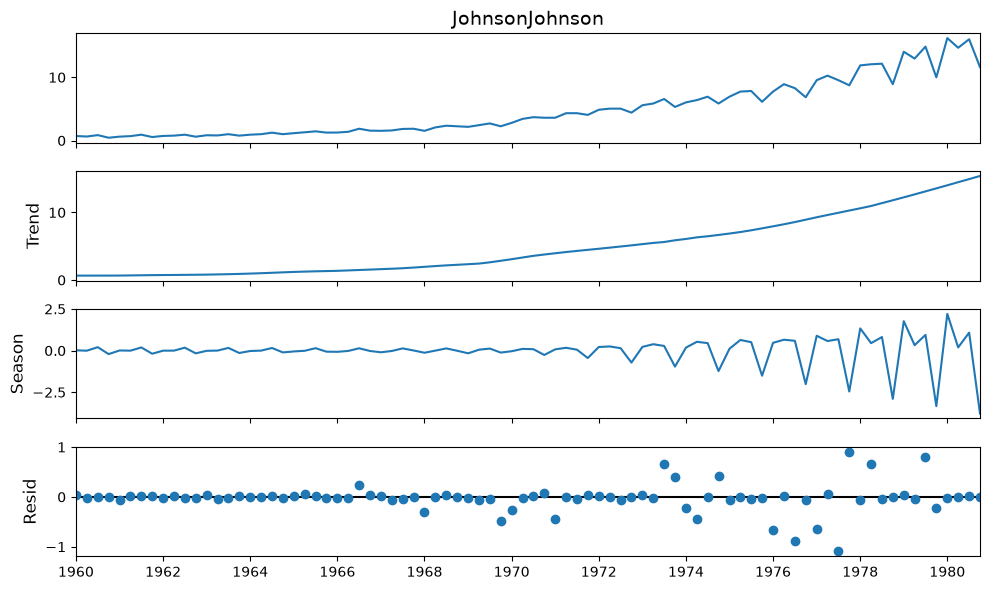

In [21]:
# Using STL
# we define the period to define the requency since our
# data series frequency is not clearly indicated
df_stl = STL(df.JohnsonJohnson, period=4, robust=True).fit()
df_stl.plot()
plt.show()

The plot has four parts:

1. This is the original observed data that we are decomposing.

2. The trend component shows an upward direction. The same as what we've seen in season_decompose.

3. The seasonal component shows the seasonality effect and it is more obvious here in this plot. It shows the repeating patterns of highs and lows.

4. The residual (noise) component shows the random variation in the data after applying the model.

#### Part 4 Other Time Series Data Preprocessing Activities

We will look at extracting years, months and days, annotating holidays, date, paydays and seasons for imputation.

In [22]:
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day

# Check if the data information has changed
# you will notice that new columns have been added
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 84 entries, 1960-01-01 to 1980-10-01
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   JohnsonJohnson  84 non-null     float64
 1   year            84 non-null     int32  
 2   month           84 non-null     int32  
 3   day             84 non-null     int32  
dtypes: float64(1), int32(3)
memory usage: 2.3 KB


In [23]:
df.tail()

,JohnsonJohnson,year,month,day
time,,,,
1979-10-01,9.99,1979,10,1
1980-01-01,16.20,1980,1,1
1980-04-01,14.67,1980,4,1
1980-07-02,16.02,1980,7,2
1980-10-01,11.61,1980,10,1


**Step 4.2 Import more libraries**

See import cell at top of notebook.

**Step 4.3 Look at Australian public holidays**

In [25]:
Australia().holidays()

[(datetime.date(2026, 1, 1), 'New year'),
 (datetime.date(2026, 1, 26), 'Australia Day'),
 (datetime.date(2026, 4, 3), 'Good Friday'),
 (datetime.date(2026, 4, 6), 'Easter Monday'),
 (datetime.date(2026, 4, 27), 'Anzac Day'),
 (datetime.date(2026, 12, 25), 'Christmas Day'),
 (datetime.date(2026, 12, 26), 'Boxing Day'),
 (datetime.date(2026, 12, 28), 'Boxing Day Shift')]

**Step 4.4 Get custom public holidays**

In [33]:
def create_custom_holidays(year: int) -> List:
    custom_holidays = AustralianCapitalTerritory().holidays()
    custom_holidays.append((
        (dt.datetime(year, 11, 1) + relativedelta(weekday=TH(4)) + dt.timedelta(days=1)).date(),
        "Black Friday"
    ))
    return {k: v for (k, v) in custom_holidays}

custom_holidays = create_custom_holidays(2022)

---

**Note** We are declaring the signature of our function like this:

**def create_custom_holidays(year: int) -> List:**

This means we are expecting an integer called year and we are expecting a List as an output.

---

In [35]:
# we now have our custom holidays for ACT
# Note that the date format follows MM/DD/YYY
custom_holidays

{datetime.date(2026, 1, 1): 'New year',
 datetime.date(2026, 1, 26): 'Australia Day',
 datetime.date(2026, 3, 9): 'Canberra Day',
 datetime.date(2026, 4, 3): 'Good Friday',
 datetime.date(2026, 4, 4): 'Easter Saturday',
 datetime.date(2026, 4, 6): 'Easter Monday',
 datetime.date(2026, 4, 27): 'Anzac Day',
 datetime.date(2026, 6, 1): 'Reconciliation Day Shift',
 datetime.date(2026, 6, 8): "Queen's Birthday",
 datetime.date(2026, 10, 5): 'Labour Day',
 datetime.date(2026, 12, 25): 'Christmas Day',
 datetime.date(2026, 12, 26): 'Boxing Day',
 datetime.date(2026, 12, 28): 'Boxing Day Shift',
 datetime.date(2022, 11, 25): 'Black Friday'}